In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

sys.path.append(os.path.abspath(".."))

from CP.classifier import SplitConformalClassifier
from CP.scores import ClassificationScores

In [3]:
data = load_iris()

X = data.data
y = data.target
target_names = data.target_names

df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp,
)

print("Train shape :", X_train.shape)
print("Calib shape :", X_calib.shape)
print("Test shape  :", X_test.shape)

Train shape : (90, 4)
Calib shape : (30, 4)
Test shape  : (30, 4)


In [6]:
results = {}

for score_type in ["probability", "cumulative", "high_probability"]:
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
    )

    score = ClassificationScores(score_type=score_type)

    cp = SplitConformalClassifier(
        model=model,
        alpha=0.1,
        score=score,
    )

    cp.fit(X_train, y_train, X_calib, y_calib)

    pred_probs = cp.predict_proba(X_test)
    pred_sets = cp.predict_set(X_test)

    coverage = np.mean([
        y_test[i] in pred_sets[i]
        for i in range(len(y_test))
    ])

    avg_set_size = np.mean([
        len(s)
        for s in pred_sets
    ])

    results[score_type] = {
        "q_hat": cp.q_hat_,
        "pred_probs": pred_probs,
        "pred_sets": pred_sets,
        "coverage": coverage,
        "avg_set_size": avg_set_size,
    }

    print(f"\n=== {score_type.upper()} ===")
    print("q_hat:", cp.q_hat_)
    print("threshold probability:", -cp.q_hat_)
    print("coverage:", coverage)
    print("average set size:", avg_set_size)


=== PROBABILITY ===
q_hat: 0.8
threshold probability: -0.8
coverage: 0.9666666666666667
average set size: 1.0333333333333334

=== CUMULATIVE ===
q_hat: 1.0
threshold probability: -1.0
coverage: 1.0
average set size: 3.0

=== HIGH_PROBABILITY ===
q_hat: -0.2
threshold probability: 0.2
coverage: 0.9666666666666667
average set size: 1.0333333333333334


In [7]:
for score_type in ["probability", "cumulative", "high_probability"]:
    print(f"\n=== {score_type.upper()} ===")

    pred_sets = results[score_type]["pred_sets"]

    for i in range(len(y_test)):
        labels = [target_names[j] for j in pred_sets[i]]

        print(
            f"sample {i:2d} | true = {target_names[y_test[i]]:10s} | set = {labels}"
        )


=== PROBABILITY ===
sample  0 | true = setosa     | set = ['setosa']
sample  1 | true = virginica  | set = ['virginica']
sample  2 | true = versicolor | set = ['versicolor']
sample  3 | true = versicolor | set = ['versicolor']
sample  4 | true = setosa     | set = ['setosa']
sample  5 | true = versicolor | set = ['versicolor']
sample  6 | true = setosa     | set = ['setosa']
sample  7 | true = setosa     | set = ['setosa']
sample  8 | true = virginica  | set = ['virginica']
sample  9 | true = versicolor | set = ['versicolor']
sample 10 | true = virginica  | set = ['virginica']
sample 11 | true = virginica  | set = ['virginica']
sample 12 | true = virginica  | set = ['virginica']
sample 13 | true = versicolor | set = ['versicolor']
sample 14 | true = setosa     | set = ['setosa']
sample 15 | true = setosa     | set = ['setosa']
sample 16 | true = setosa     | set = ['setosa']
sample 17 | true = versicolor | set = ['versicolor']
sample 18 | true = versicolor | set = ['versicolor']
sampl

In [8]:
for score_type in ["probability", "cumulative", "high_probability"]:
    print(f"\n{'=' * 60}")
    print(f"SCORE TYPE: {score_type.upper()}")
    print(f"{'=' * 60}")

    pred_probs = results[score_type]["pred_probs"]
    pred_sets = results[score_type]["pred_sets"]
    

    for i in range(len(y_test)):
        probs = pred_probs[i]
        pred_set = pred_sets[i]

        prob_text = ", ".join([
            f"{target_names[j]}: {probs[j]:.3f}"
            for j in range(len(target_names))
        ])

        set_text = ", ".join([
            target_names[j]
            for j in pred_set
        ])

        print(f"Sample {i:2d}")
        print(f"  True label      : {target_names[y_test[i]]}")
        print(f"  Probabilities   : {prob_text}")
        print(f"  Prediction set  : {{{set_text}}}")
        print()


SCORE TYPE: PROBABILITY
Sample  0
  True label      : setosa
  Probabilities   : setosa: 1.000, versicolor: 0.000, virginica: 0.000
  Prediction set  : {setosa}

Sample  1
  True label      : virginica
  Probabilities   : setosa: 0.000, versicolor: 0.075, virginica: 0.925
  Prediction set  : {virginica}

Sample  2
  True label      : versicolor
  Probabilities   : setosa: 0.025, versicolor: 0.830, virginica: 0.145
  Prediction set  : {versicolor}

Sample  3
  True label      : versicolor
  Probabilities   : setosa: 0.025, versicolor: 0.935, virginica: 0.040
  Prediction set  : {versicolor}

Sample  4
  True label      : setosa
  Probabilities   : setosa: 1.000, versicolor: 0.000, virginica: 0.000
  Prediction set  : {setosa}

Sample  5
  True label      : versicolor
  Probabilities   : setosa: 0.000, versicolor: 0.980, virginica: 0.020
  Prediction set  : {versicolor}

Sample  6
  True label      : setosa
  Probabilities   : setosa: 1.000, versicolor: 0.000, virginica: 0.000
  Predict

In [12]:
np.random.seed(42)

n_points = 10
indices = np.random.choice(len(X_test), size=n_points, replace=False)

n_classes = len(target_names)
class_labels = list(target_names)

probability_matrix = np.zeros((n_points, n_classes))
cumulative_matrix = np.zeros((n_points, n_classes))
high_prob_matrix = np.zeros((n_points, n_classes))

for i, idx in enumerate(indices):
    probs = results["probability"]["pred_probs"][idx]

    probability_set = results["probability"]["pred_sets"][idx]
    cumulative_set = results["cumulative"]["pred_sets"][idx]
    high_prob_set = results["high_probability"]["pred_sets"][idx]

    for c in probability_set:
        probability_matrix[i, c] =  probs[c]

    for c in cumulative_set:
        cumulative_matrix[i, c]  =  probs[c]

    for c in high_prob_set:
        high_prob_matrix[i,c]    =  probs[c]

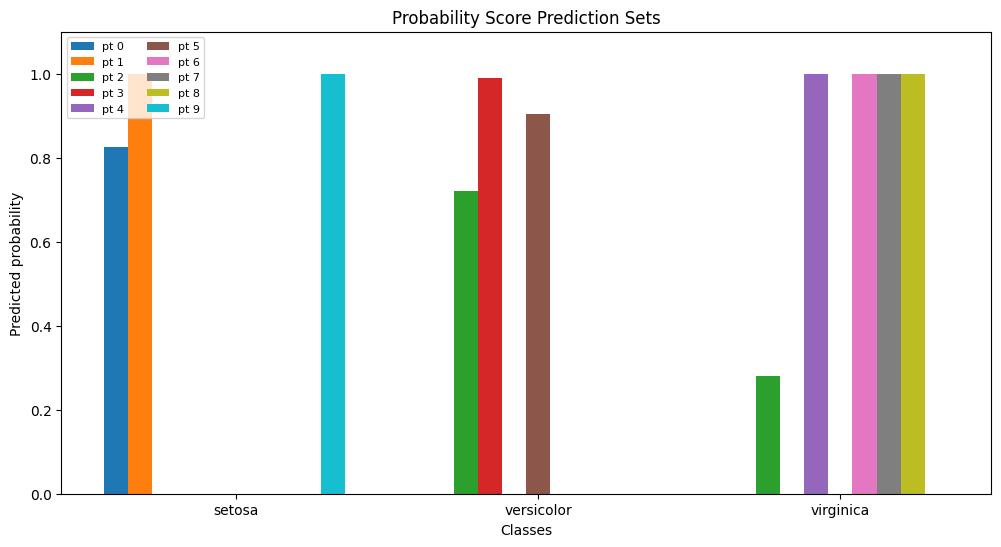

In [13]:
x = np.arange(n_classes)
width = 0.08

plt.figure(figsize=(12, 6))

for i in range(n_points):
    plt.bar(
        x + i * width,
        probability_matrix[i],
        width=width,
        label=f"pt {i}",
    )

plt.xticks(x + width * 5, class_labels)
plt.ylim(0, 1.1)
plt.title("Probability Score Prediction Sets")
plt.ylabel("Predicted probability")
plt.xlabel("Classes")
plt.legend(ncol=2, fontsize=8)
plt.show()

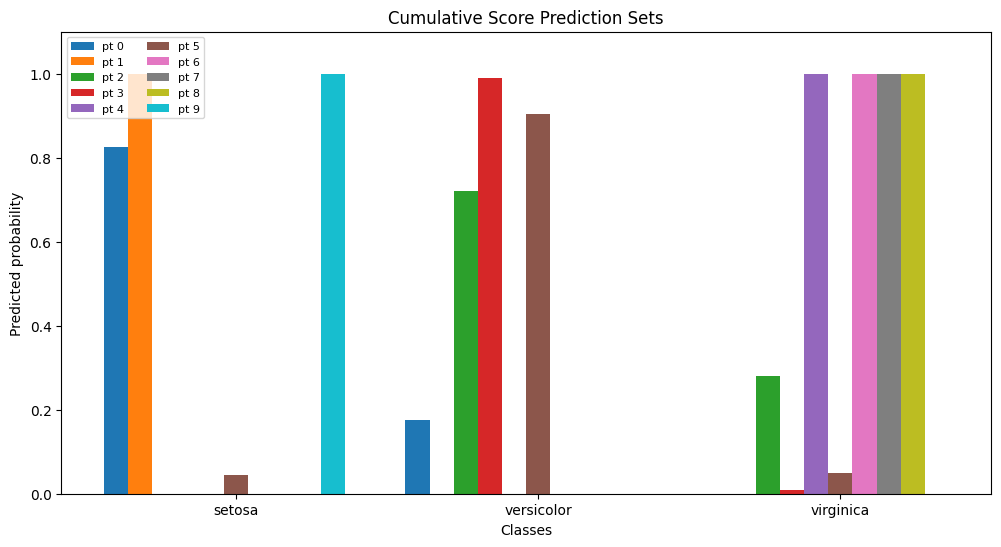

In [11]:
plt.figure(figsize=(12, 6))

for i in range(n_points):
    plt.bar(
        x + i * width,
        cumulative_matrix[i],
        width=width,
        label=f"pt {i}",
    )

plt.xticks(x + width * 5, class_labels)
plt.ylim(0, 1.1)
plt.title("Cumulative Score Prediction Sets")
plt.ylabel("Predicted probability")
plt.xlabel("Classes")
plt.legend(ncol=2, fontsize=8)
plt.show()

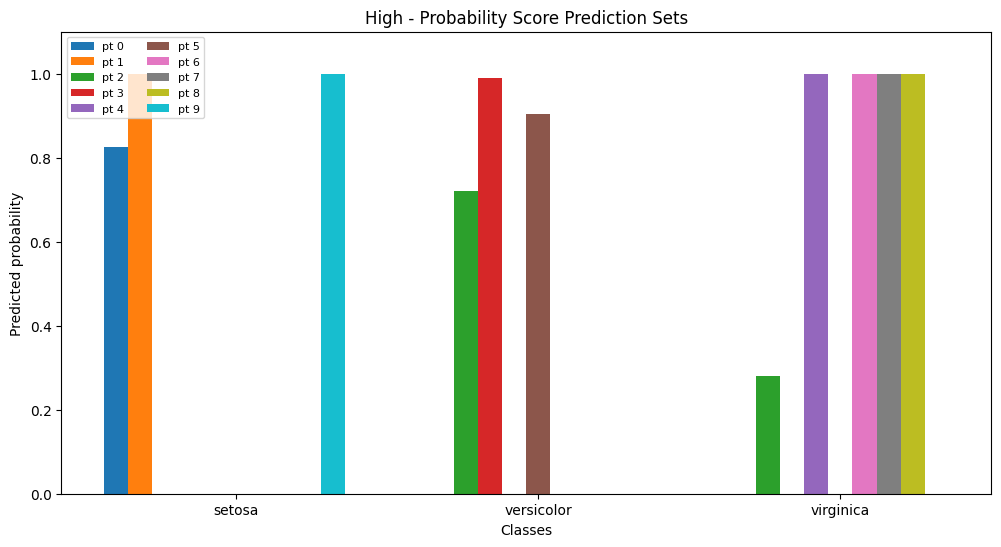

In [14]:
plt.figure(figsize=(12, 6))

for i in range(n_points):
    plt.bar(
        x + i * width,
        high_prob_matrix[i],
        width=width,
        label=f"pt {i}",
    )

plt.xticks(x + width * 5, class_labels)
plt.ylim(0, 1.1)
plt.title("High - Probability Score Prediction Sets")
plt.ylabel("Predicted probability")
plt.xlabel("Classes")
plt.legend(ncol=2, fontsize=8)
plt.show()

In [15]:
print("\n========== FINAL EVALUATION ==========")

for score_type, res in results.items():
    pred_sets = res["pred_sets"]

    covered = np.array([
        y_test[i] in pred_sets[i]
        for i in range(len(y_test))
    ])

    set_sizes = np.array([
        len(pred_sets[i])
        for i in range(len(pred_sets))
    ])

    print(f"\n--- Score function: {score_type} ---")
    print(f"q_hat: {res['q_hat']:.4f}")
    print(f"Coverage: {covered.mean():.4f}")
    print(f"Average set size: {set_sizes.mean():.4f}")

    print("First 10 prediction sets:")

    for i in range(min(10, len(y_test))):
        label_set = [target_names[j] for j in pred_sets[i]]

        print(
            f"Sample {i}: "
            f"true={target_names[y_test[i]]}, "
            f"pred_set={label_set}, "
            f"covered={y_test[i] in pred_sets[i]}"
        )

    print("Per-class coverage:")

    for cls in np.unique(y_test):
        idx = np.where(y_test == cls)[0]

        cls_coverage = np.mean([
            y_test[i] in pred_sets[i]
            for i in idx
        ])

        cls_avg_size = np.mean([
            len(pred_sets[i])
            for i in idx
        ])

        print(
            f"  class {target_names[cls]}: "
            f"coverage={cls_coverage:.4f}, "
            f"avg_set_size={cls_avg_size:.4f}"
        )


========== FINAL EVALUATION ==========

--- Score function: probability ---
q_hat: 0.8000
Coverage: 0.9667
Average set size: 1.0333
First 10 prediction sets:
Sample 0: true=setosa, pred_set=['setosa'], covered=True
Sample 1: true=virginica, pred_set=['virginica'], covered=True
Sample 2: true=versicolor, pred_set=['versicolor'], covered=True
Sample 3: true=versicolor, pred_set=['versicolor'], covered=True
Sample 4: true=setosa, pred_set=['setosa'], covered=True
Sample 5: true=versicolor, pred_set=['versicolor'], covered=True
Sample 6: true=setosa, pred_set=['setosa'], covered=True
Sample 7: true=setosa, pred_set=['setosa'], covered=True
Sample 8: true=virginica, pred_set=['virginica'], covered=True
Sample 9: true=versicolor, pred_set=['versicolor'], covered=True
Per-class coverage:
  class setosa: coverage=1.0000, avg_set_size=1.0000
  class versicolor: coverage=0.9000, avg_set_size=1.0000
  class virginica: coverage=1.0000, avg_set_size=1.1000

--- Score function: cumulative ---
q_hat